In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Circle
%matplotlib ipympl

In [2]:

def countsReturner(file_path):
    try:
        df = pd.read_csv(file_path, header=None, comment="#", on_bad_lines="skip")

        df.columns = ['EventID', 'TrackID', 'Particle', 'EnergyDeposited',
                    'LocalTime', 'Volume', 'Copynumber', 'Initial Energy',
                        'Origin Volume', 'ParentID', 'ProcessName']
        counts = []
        scintillationdf = df.loc[df['ProcessName'] == 'Scintillation']

        for i in scintillationdf['EventID'].unique():
            newdf = scintillationdf.loc[df['EventID'] == i]
            # print(newdf.groupby("Copynumber").size())
            # print(newdf.groupby("Copynumber").size().reset_index(name="PhotonCount").to_numpy())
            sipm_counts = newdf.groupby("Copynumber").size().reset_index(name="PhotonCount")
            # print(sipm_counts)
            try:             
                counts.append([i, sipm_counts.to_numpy().T])
            except:
                pass
        return counts
    except:
        print("oop no counts sori")
        pass
        
    


In [3]:

path = "/home/joeyl/Documents/cosmic-geant/build/output"

files = os.listdir(path)

big_array = []

for file in files:
    address = path + '/' + file
    big_array.append(countsReturner(address))




In [11]:
def circleChecker(sipm_x, sipm_y, radius, candidate):
    if(candidate[0]-sipm_x)**2 + (candidate[1]-sipm_y)**2 <= radius**2:
        return True
    else:
        return False

In [12]:
def radius_calcualtor(photonCount, max):
    return((2.429/(photonCount/max + 0.33))**2 * 10)

In [17]:
def process_data(array, plot=False):
    spacing = 62.5
    coords = array[1][0]
    rows = coords % 10
    cols = coords // 10
    vals = array[1][1]

    

    # photon counts (your actual data)

    weights = [i for i in vals]  # replace with your photon counts array

    x_mm = 31.25+ cols * spacing
    y_mm = 31.25+ rows * spacing
    
    sipm_x = cols * spacing + 31.25
    sipm_y = rows * spacing + 31.25

    radii = [radius_calcualtor(val, max(weights)) for val in weights]
    #radiusError = (2*np.array(weights)**(-3/2))*(2.42**2) * 10
    #print(radii)
    #print(radiusError)
    if plot:
        fig, ax = plt.subplots()
        ax.scatter(sipm_x, sipm_y)
        for i in range(len(weights)):
            ax.add_patch(Circle((sipm_x[i], sipm_y[i]), radii[i], fill=False))
        ax.set_xlim(0, 500)
        ax.set_ylim(0, 500)
        ax.set_aspect('equal')
    

        # centroid calculation
        #x_rec = np.sum(new_vals * x_mm) / np.sum(new_vals)
        #y_rec = np.sum(new_vals * y_mm) / np.sum(new_vals)


    return (sipm_x, sipm_y, radii, weights)

In [24]:
def circleChecker(sipm_x, sipm_y, radius, candidate):
    if(candidate[0]-sipm_x)**2 + (candidate[1]-sipm_y)**2 <= radius**2:
        return True
    else:
        return False

In [25]:
def bandChecker(sipm_x, sipm_y, radius, candidate, photons):
    radiusError = 2*photons**(-3/2)*2.42**2 * 10
    radiusError = 30
    distance = (candidate[0]-sipm_x)**2 + (candidate[1]-sipm_y)**2
    if distance >= (radius - radiusError)**2 and distance <= (radius + radiusError)**2:
        return True
    else:
        return False

In [18]:


def old_process_data(array):
    coords = array[1][0]
    rows = coords % 10
    cols = coords // 10
    vals = array[1][1]
    x_mm = 31.25+ cols * spacing
    y_mm = 31.25+rows * spacing

    # photon counts (your actual data)
    weights = vals  # replace with your photon counts array

    # centroid calculation
    x_rec = np.sum(weights * x_mm) / np.sum(weights)
    y_rec = np.sum(weights * y_mm) / np.sum(weights)

    return (x_rec,y_rec)

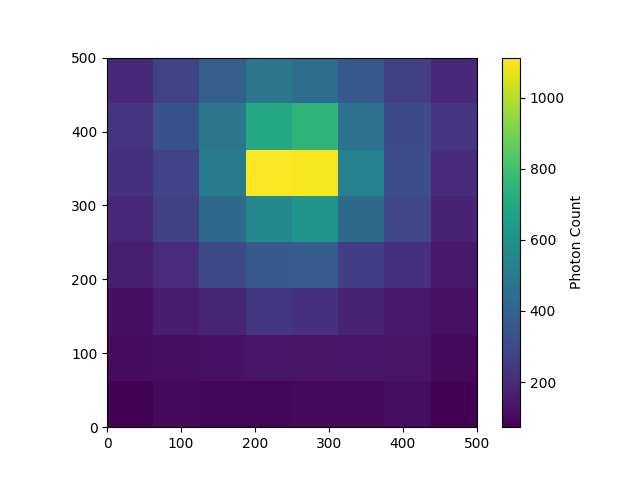

In [19]:
event = big_array[10][1][1]
coords = event[0]
rows = coords % 10
cols = coords // 10
vals = event[1]

grid = np.zeros((rows.max()+1, cols.max()+1))
grid[rows, cols] = vals
fig, ax = plt.subplots()

ax.imshow(grid, origin='lower', extent=(0, 500, 0, 500))
fig.colorbar(ax.imshow(grid, origin='lower', extent=(0, 500, 0, 500)), ax=ax, label='Photon Count')

#plt.scatter(rows*spacing+31.25,vals)

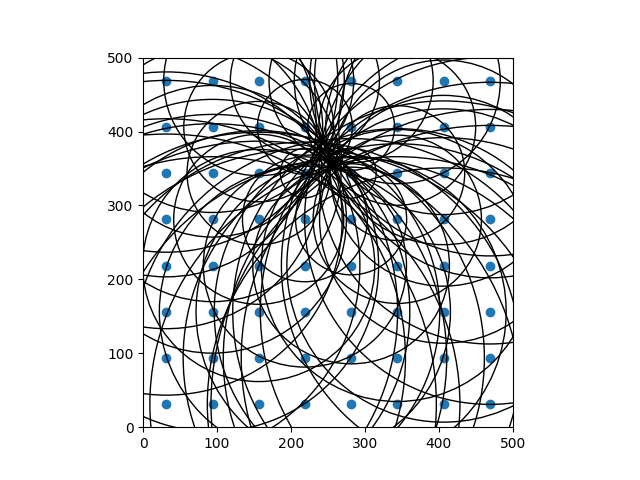

In [20]:
results = process_data(big_array[10][1], plot=True)

In [23]:
candidates = np.array([[i, j] for i in range(501) for j in range(501)])
numberOfCircles = np.zeros(len(candidates))
for i in range(len(candidates)):
    for j in range(len(results[0])):
        if bandChecker(results[0][j], results[1][j], results[2][j], candidates[i], results[3][j]):
            numberOfCircles[i] += 1


[np.float64(243.5483870967742), np.float64(360.93548387096774)]


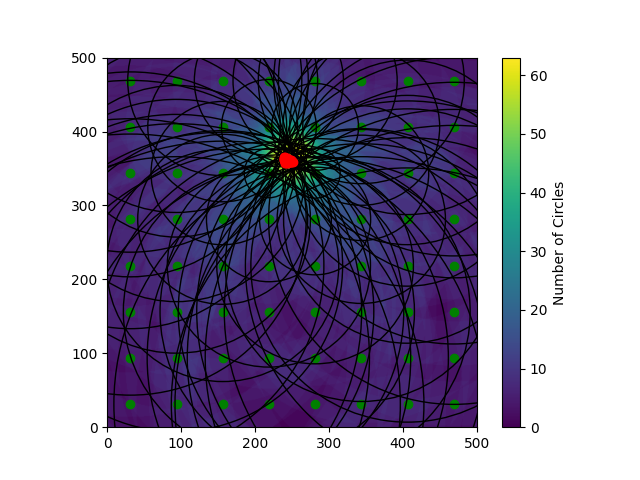

In [35]:
best = np.where(numberOfCircles == max(numberOfCircles))


fig, ax = plt.subplots()

# plot the colourmap 
ax.imshow(numberOfCircles.reshape(501, 501), origin='lower', extent=(0, 500, 0, 500), cmap='viridis')
fig.colorbar(ax.imshow(numberOfCircles.reshape(501, 501).T, origin='lower', extent=(0, 500, 0, 500), cmap='viridis'), ax=ax, label='Number of Circles')

#plot the sipm positions
sipm_x, sipm_y, radii, weights = results
ax.scatter(sipm_x, sipm_y, color='green', label='SiPM Positions')

#plot the circles
for i in range(len(weights)):
    ax.add_patch(Circle((sipm_x[i], sipm_y[i]), radii[i], fill=False))

# plot the best candidates
ax.scatter([i[0] for i in candidates[best]], [i[1] for i in candidates[best]], color='red', label='Best Candidate')

# nicieties
ax.set_xlim(0, 500)
ax.set_ylim(0, 500)
result = [np.average(candidates[best].T[0]), np.average(candidates[best].T[1])]
print(result)


In [44]:
def ultimateProcessor(array, plot=False):
    results = process_data(array, plot=False)

    candidates = np.array([[i, j] for i in range(501) for j in range(501)])

    numberOfCircles = np.zeros(len(candidates))

    for i in range(len(candidates)):
        for j in range(len(results[0])):
            if bandChecker(results[0][j], results[1][j], results[2][j], candidates[i], results[3][j]):
                numberOfCircles[i] += 1
    
    best = np.where(numberOfCircles == max(numberOfCircles))

    if plot:
        sipm_x, sipm_y, radii, weights = results
        fig, ax = plt.subplots(2, 2)

        event = array[1]
        coords = event[0]
        rows = coords % 10
        cols = coords // 10
        vals = event[1]

        grid = np.zeros((rows.max()+1, cols.max()+1))
        grid[rows, cols] = vals
        ax[0][0].imshow(grid, origin='lower', extent=(0, 500, 0, 500), cmap='viridis')
        fig.colorbar(ax[0][0].imshow(grid, origin='lower', extent=(0, 500, 0, 500), cmap='viridis'), ax=ax[0][0], label='Photon Count')

        ax[0][1].scatter(sipm_x, sipm_y)
        for i in range(len(weights)):
            ax[0][1].add_patch(Circle((sipm_x[i], sipm_y[i]), radii[i], fill=False))
        ax[0][1].set_xlim(0, 500)
        ax[0][1].set_ylim(0, 500)
        ax[0][1].set_aspect('equal')
    

        # plot the colourmap 
        ax[1][0].imshow(numberOfCircles.reshape(501, 501), origin='lower', extent=(0, 500, 0, 500), cmap='viridis')
        fig.colorbar(ax[1][0].imshow(numberOfCircles.reshape(501, 501).T, origin='lower', extent=(0, 500, 0, 500), cmap='viridis'), ax=ax[1][0], label='Number of Circles')

        #plot the sipm positions
        
        #ax[1][1].scatter(sipm_x, sipm_y, color='green', label='SiPM Positions')

        #plot the circles
        #for i in range(len(weights)):
        #    ax[1][1].add_patch(Circle((sipm_x[i], sipm_y[i]), radii[i], fill=False))

        # plot the best candidates
        ax[1][0].scatter([i[0] for i in candidates[best]], [i[1] for i in candidates[best]], color='red', label='Best Candidate')

        # nicieties
        ax[1][0].set_xlim(0, 500)
        ax[1][0].set_ylim(0, 500)
    result = [np.average(candidates[best].T[0]), np.average(candidates[best].T[1])]
    return(result)

[np.float64(243.5483870967742), np.float64(360.93548387096774)]

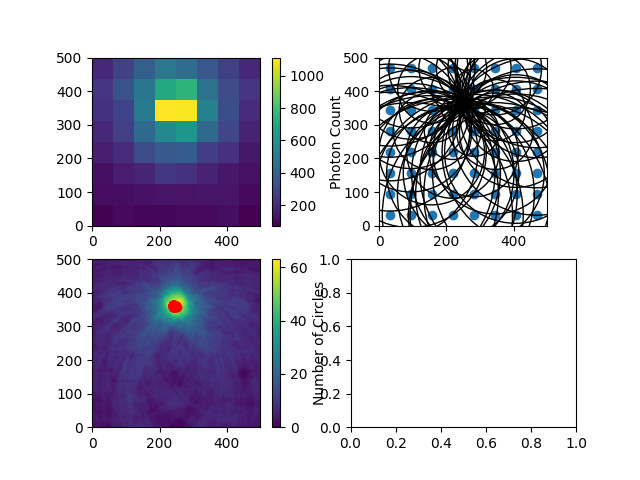

In [45]:
ultimateProcessor(big_array[10][1], plot=True)